In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from typing import Optional

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_gaussian_quantiles

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.metrics import classification_report, log_loss

import warnings
warnings.filterwarnings('ignore')

In [5]:
def make_dataset(n: int = 100, random_seed: int = None):
    n_per_class = int(n/2)
    if random_seed:
        np.random.seed(random_seed)
    X, y = make_gaussian_quantiles(n_samples=n, n_features=2, n_classes=2)
    return X, y*2-1

X, y = make_dataset(n=30, random_seed=10)

In [6]:
def check(y):
    assert set(y) == {-1,1}
    return y

In [8]:
def predict(X, stumps, stump_weights):
    stump_preds = np.array([stump.predict(X) for stump in stumps])
    return np.sign(np.dot(stump_weights, stump_preds))

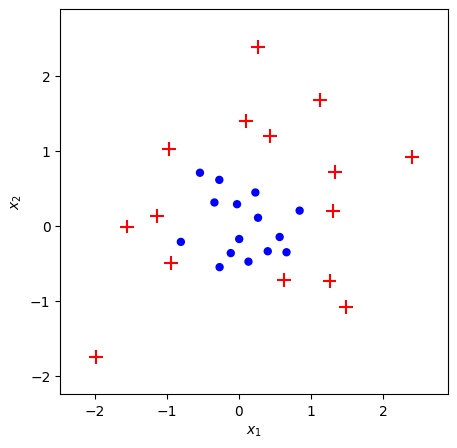

In [9]:
def plot_adaboost(X: np.ndarray,
                  y: np.ndarray,
                  stumps= None, stump_weights= None, roll = 0,
                  clf= None,
                  sample_weights: Optional[np.ndarray] = None,
                  ax: Optional[mpl.axes.Axes] = None):

    y = check(y) # Kì vọng nhãn bằng ±1

    if not ax:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
        fig.set_facecolor('white')

    pad = 1
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad

    if sample_weights is not None:
        sizes = np.array(sample_weights) * X.shape[0] * 100  
    else:
        sizes = np.ones(shape=X.shape[0]) * 100

    X_pos = X[y == 1]
    sizes_pos = sizes[y == 1]
    ax.scatter(*X_pos.T, s=sizes_pos, marker='+', color='red')

    X_neg = X[y == -1]
    sizes_neg = sizes[y == -1]
    ax.scatter(*X_neg.T, s=sizes_neg, marker='.', c='blue')

    if clf:
        plot_step = 0.01
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # If all predictions are positive class, adjust color map acordingly
        if list(np.unique(Z)) == [1]:
            fill_colors = ['r']
        else:
            fill_colors = ['b', 'r']

        ax.contourf(xx, yy, Z, colors=fill_colors, alpha=0.2)

    if roll:
        plot_step = 0.01
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))

        Z = predict(np.c_[xx.ravel(), yy.ravel()], stumps, stump_weights)
        Z = Z.reshape(xx.shape)

        # If all predictions are positive class, adjust color map acordingly
        if list(np.unique(Z)) == [1]:
            fill_colors = ['r']
        else:
            fill_colors = ['b', 'r']

        ax.contourf(xx, yy, Z, colors=fill_colors, alpha=0.2)

    ax.set_xlim(x_min+0.5, x_max-0.5)
    ax.set_ylim(y_min+0.5, y_max-0.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plot_adaboost(X, y)

Train error: 0.0%


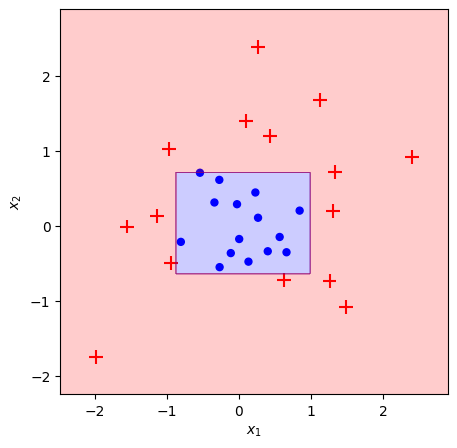

In [10]:
clf = AdaBoostClassifier(n_estimators=15, algorithm='SAMME').fit(X, y)
plot_adaboost(X, y, clf=clf)

train_err = (clf.predict(X) != y).mean()
print(f'Train error: {train_err:.1%}')